Regressione LASSO

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Lasso, LassoCV, LinearRegression

In [4]:
data = fetch_california_housing(as_frame=True)
X = data.data
y = data.target

display(X)
display(y)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

In [5]:
# come prima cosa dobbiamo scalare i dati

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
display(X_scaled)

array([[ 2.34476576,  0.98214266,  0.62855945, ..., -0.04959654,
         1.05254828, -1.32783522],
       [ 2.33223796, -0.60701891,  0.32704136, ..., -0.09251223,
         1.04318455, -1.32284391],
       [ 1.7826994 ,  1.85618152,  1.15562047, ..., -0.02584253,
         1.03850269, -1.33282653],
       ...,
       [-1.14259331, -0.92485123, -0.09031802, ..., -0.0717345 ,
         1.77823747, -0.8237132 ],
       [-1.05458292, -0.84539315, -0.04021111, ..., -0.09122515,
         1.77823747, -0.87362627],
       [-0.78012947, -1.00430931, -0.07044252, ..., -0.04368215,
         1.75014627, -0.83369581]], shape=(20640, 8))

In [7]:
# come baseline andiamo ad allenare una regresione lineare

lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y)
y_pred_lin = lin_reg.predict(X_scaled)

mse_lin = mean_squared_error(y, y_pred_lin)
r2_lin = r2_score(y, y_pred_lin)

print(f"MSE:\t{mse_lin}\nR2:{r2_lin}")

MSE:	0.5243209861846072
R2:0.606232685199805


In [13]:
# valutazione della regressione LASSO

r2_lasso = []
mse_lasso = []
alphas = np.logspace(-4, 10, 100)

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X_scaled, y)
    y_pred = lasso.predict(X_scaled)
    mse_lasso.append(mean_squared_error(y, y_pred))
    r2_lasso.append(r2_score(y, y_pred))

# andiamo a mettere il risultato in un dataframe
results = pd.DataFrame({"alphas":alphas, "MSE":mse_lasso, "R2":r2_lasso})
display(results)


,alphas,MSE,R2
0,1.000000e-04,0.524322,0.606232
1,1.384886e-04,0.524322,0.606232
2,1.917910e-04,0.524323,0.606231
3,2.656088e-04,0.524325,0.606230
4,3.678380e-04,0.524329,0.606227
...,...,...,...
95,2.718588e+09,1.331550,0.000000
96,3.764936e+09,1.331550,0.000000
97,5.214008e+09,1.331550,0.000000
98,7.220809e+09,1.331550,0.000000


In [14]:
# indice minimo del valore mse e vedere a quale alpha corrisponde e quale valore ha

best_idx_man = np.argmin(mse_lasso)
best_alpha_man = alphas[best_idx_man]
best_mse_man = mse_lasso[best_idx_man]
best_r2_man = r2_lasso[best_idx_man]

print(f"Alpha LASSO:\t{best_alpha_man:.4f}\nMSE:\t{best_mse_man:.4f}\nR2:\t{best_r2_man:.4f}")

Alpha LASSO:	0.0001
MSE:	0.5243
R2:	0.6062


In [15]:
# regressione LASSO con cross-validation

alphas_cv = alphas
lasso_cv = LassoCV(alphas=alphas_cv, cv = 5, random_state=42, max_iter=1000)
lasso_cv.fit(X_scaled, y)

print(f"alpha LASSOCV:\t{lasso_cv.alpha_}")

y_pred_cv = lasso_cv.predict(X_scaled)
mse_cv = mean_squared_error(y, y_pred_cv)
r2_cv = r2_score(y, y_pred_cv)

print(f"MSE LASSOCV:\t{mse_cv}\nR2:\t{r2_cv}")

alpha LASSOCV:	0.002595024211399737
MSE LASSOCV:	0.52469805360532
R2:	0.6059495059457508


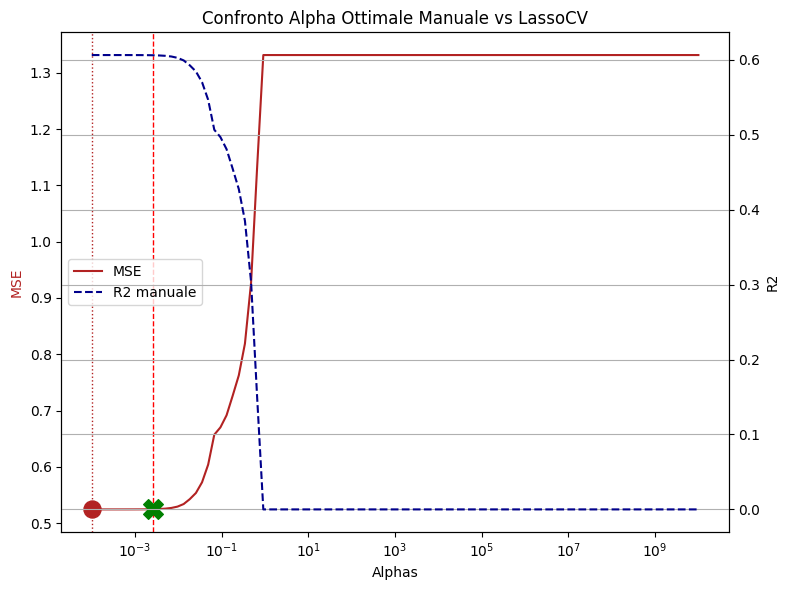

In [16]:
# plot di entrambi i valori di alpha trovati

fig, ax1 = plt.subplots(figsize = (8,6))
l1 = ax1.plot(alphas, mse_lasso, "-", color="firebrick", label = "MSE")
ax1.set_xscale("log")
ax1.set_xlabel("Alphas")
ax1.set_ylabel("MSE", color="firebrick")

# scatter plot degli alpha manuali
ax1.scatter(best_alpha_man, best_mse_man, color="firebrick", s=150, zorder=5, label=f"Alpha ottimale manuale")
ax1.axvline(best_alpha_man, color="firebrick", linestyle=":", linewidth=1)

# scatter plot dell'alpha trovato con la cross validation
ax1.scatter(lasso_cv.alpha_, mean_squared_error(y, lasso_cv.predict(X_scaled)),
            color = "green", marker = "X", s=200, zorder=5,
            label = f"alpha Ridge={lasso_cv.alpha_:.4f}")
ax1.axvline(lasso_cv.alpha_, color="red", linestyle="--", linewidth=1)

ax2 = ax1.twinx()
l2 = ax2.plot(alphas, r2_lasso, "--", color="darkblue", label="R2 manuale")
ax2.set_ylabel("R2")

plt.title(f"Confronto Alpha Ottimale Manuale vs LassoCV")
plt.grid()

lines = l1+l2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc = "center left")

plt.tight_layout()
plt.show()